In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Reshape, Activation, Flatten,
    BatchNormalization, UpSampling2D, Conv2D, MaxPooling2D
)


def generator_model():
    model = Sequential([
        Dense(input_dim=100, units=1024, activation='tanh'),
        Dense(128*7*7),
        BatchNormalization(),
        Activation('tanh'),
        Reshape((7, 7, 128), input_shape=(128*7*7,)),
        UpSampling2D(size=(2, 2)),
        Conv2D(64, (5, 5), padding='same'),
        Activation('tanh'),
        UpSampling2D(size=(2, 2)),
        Conv2D(1, (5, 5), padding='same'),
        Activation('tanh'),
    ])
    return model

In [2]:
g = generator_model()
g.summary()

C:\Users\yathi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\yathi\anaconda3\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │         103,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6272)                │       6,428,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 6272)                │          25,088 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 14, 14, 64)          │         204,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 1)           │           1,601 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,763,777 (25.80 MB)

 Trainable params: 6,751,233 (25.75 MB)

 Non-trainable params: 12,544 (49.00 KB)

In [3]:
def discriminator_model():
    model = Sequential([  
        Conv2D(
            64,
            (5, 5),
            padding='same',
            input_shape=(28, 28, 1)
        ),
        Activation('tanh'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (5, 5)),
        Activation('tanh'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(1024),
        Activation('tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

In [13]:
def chain_generator_discriminator(g, d):
    model = Sequential()
    model.add(g)
    model.add(d)
    return model

In [22]:
import math

def combine_images(generated_images):
    num = generated_images.shape[0]
    width = int(math.sqrt(num))
    height = int(math.ceil(float(num)/width))
    shape = generated_images.shape[1:3]
    image = np.zeros((height*shape[0], width*shape[1]),
                     dtype=generated_images.dtype)
    for index, img in enumerate(generated_images):
        i = int(index/width)
        j = index % width
        image[i*shape[0]:(i+1)*shape[0], j*shape[1]:(j+1)*shape[1]] = \
            img[:, :, 0]
    return image


In [33]:
from tqdm.notebook import trange
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import SGD
import numpy as np
from PIL import Image


def train(batch_size):
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    X_train = (X_train.astype(np.float32) - 127.5) / 127.5
    X_train = X_train[:, :, :, None]
    X_test = X_test[:, :, :, None]
    # X_train = X_train.reshape((X_train.shape, 1) + X_train.shape[1:])
    d = discriminator_model()
    g = generator_model()
    d_on_g = chain_generator_discriminator(g, d)
    d_optim = SGD(learning_rate=0.0005, momentum=0.9, nesterov=True)
    g_optim = SGD(learning_rate=0.0005, momentum=0.9, nesterov=True)
    g.compile(loss='binary_crossentropy', optimizer="SGD")
    d_on_g.compile(loss='binary_crossentropy', optimizer=g_optim)
    d.trainable = True
    d.compile(loss='binary_crossentropy', optimizer=d_optim)
    nbatches = X_train.shape[0] // batch_size
    generator_losses = []
    discriminator_losses = []
    for epoch in trange(10):
        print("Epoch {}".format(epoch))
        for index in trange(min(nbatches, 50)):
            noise = np.random.uniform(-1, 1, size=(batch_size, 100))
            image_batch = X_train[index*batch_size:(index+1)*batch_size]
            generated_images = g.predict(noise, verbose=0)
            if index % 20 == 0:
                image = combine_images(generated_images)
                image = image*127.5+127.5
                Image.fromarray(
                    image.astype(np.uint8)
                ).save(r'../../Drive/MyDrive/GAN/{}_{}.png'.format(epoch, index))
            X = np.concatenate(
                (image_batch, generated_images)
            )
            y = np.array(
                [1] * batch_size + [0] * batch_size
            )  # concatenated true (1) and fake (0)
            d_loss = d.train_on_batch(X, y)
            # print("batch %d d_loss : %f" % (index, d_loss))
            discriminator_losses.append(d_loss)
            noise = np.random.uniform(-1, 1, (batch_size, 100))
            d.trainable = False
            targets = np.array([1] * batch_size)  # log(1−D(G(x)))
            g_loss = d_on_g.train_on_batch(noise, targets)
            d.trainable = True
            generator_losses.append(g_loss)
            # print("batch %d g_loss : %f" % (index, g_loss))
        if index % 10 == 0 and index > 0:
            g.save_weights(r'../../Drive/MyDrive/GAN/generator.tf', True)
            d.save_weights(r'../../Drive/MyDrive/GAN/discriminator.tf', True)
                
    return discriminator_losses, generator_losses

In [34]:
batch_size = 10
discriminator_losses, generator_losses = train(batch_size)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 0


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/50 [00:00<?, ?it/s]

In [44]:
import matplotlib
import matplotlib.pyplot as plt

font = {'family' : 'calibri',
        'weight' : 'bold',
        'size'   : 17}

# matplotlib.rc('font', **font)

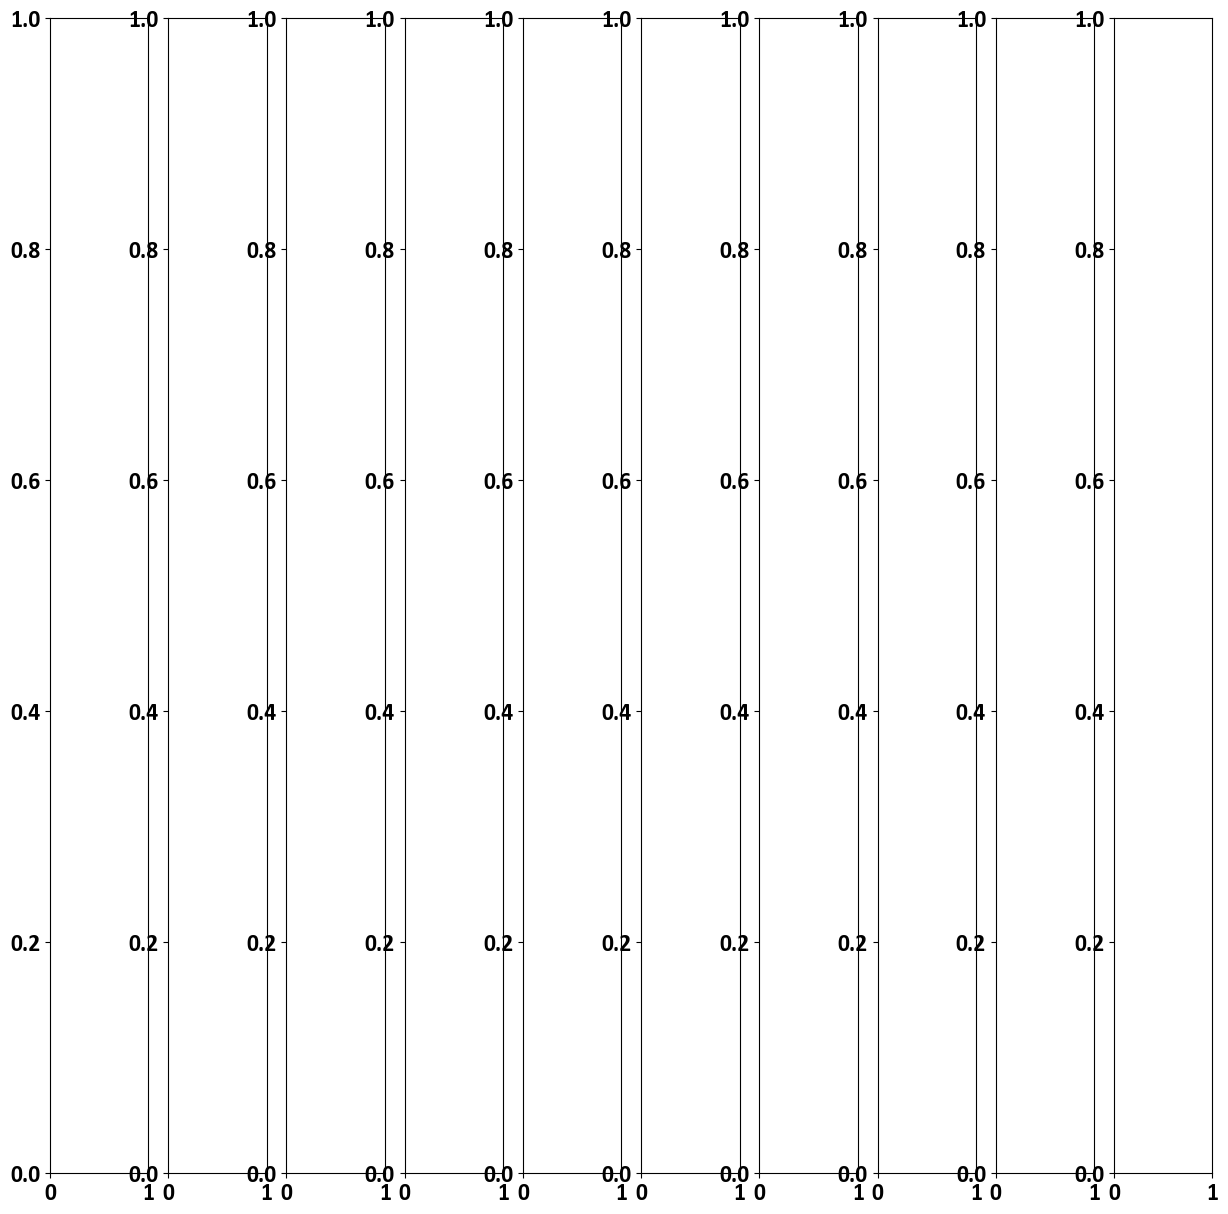

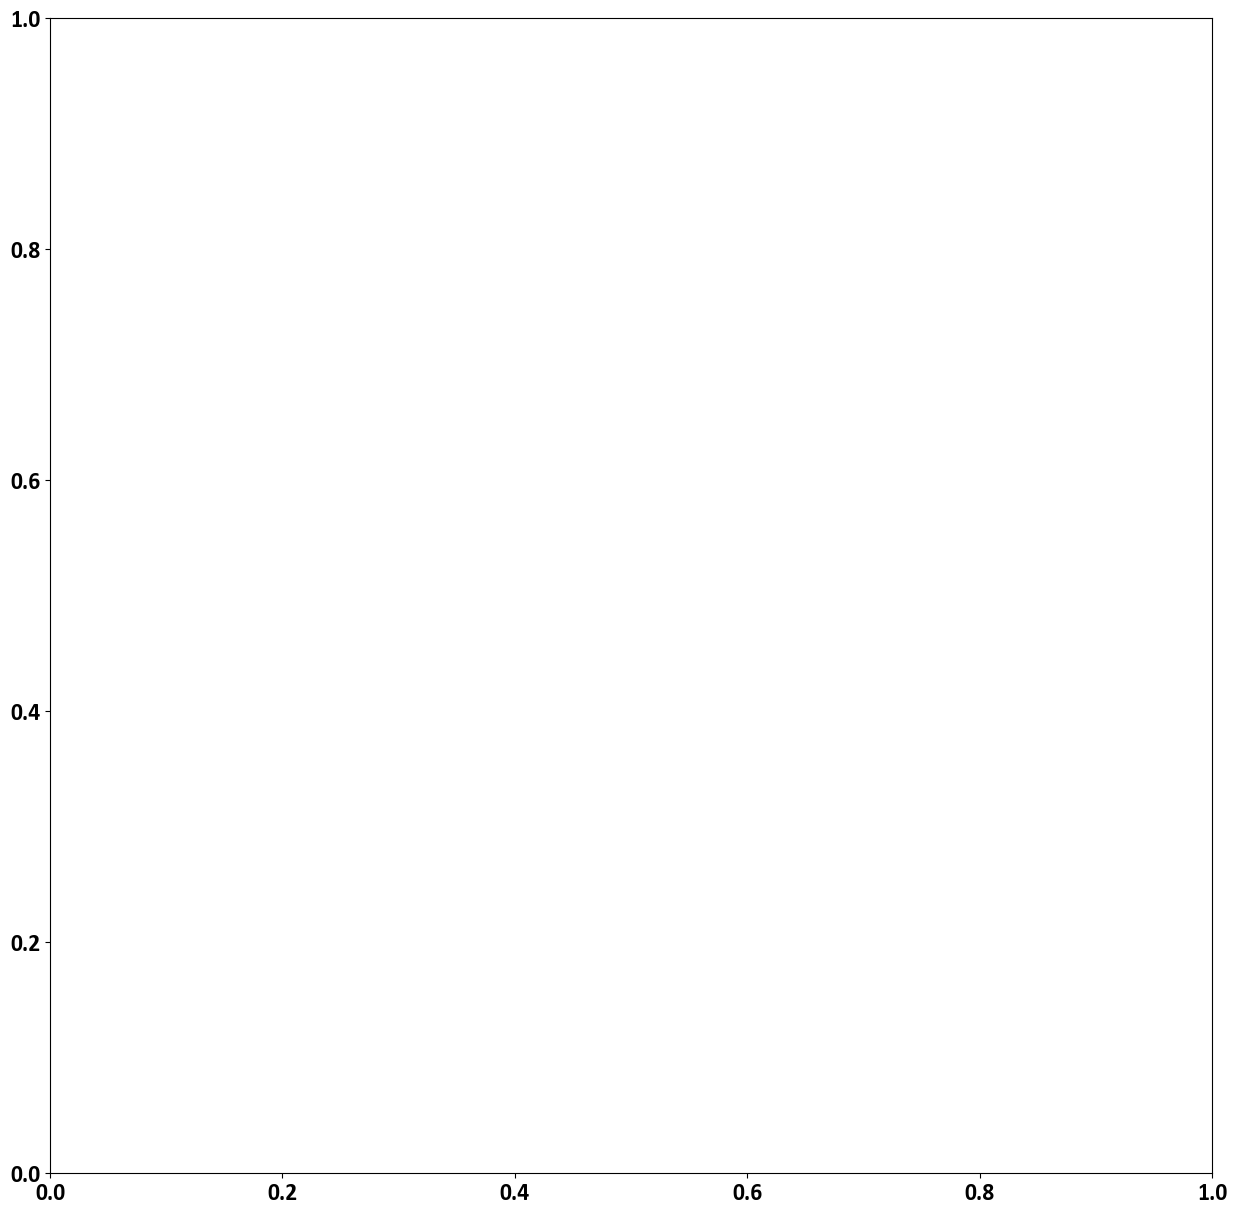

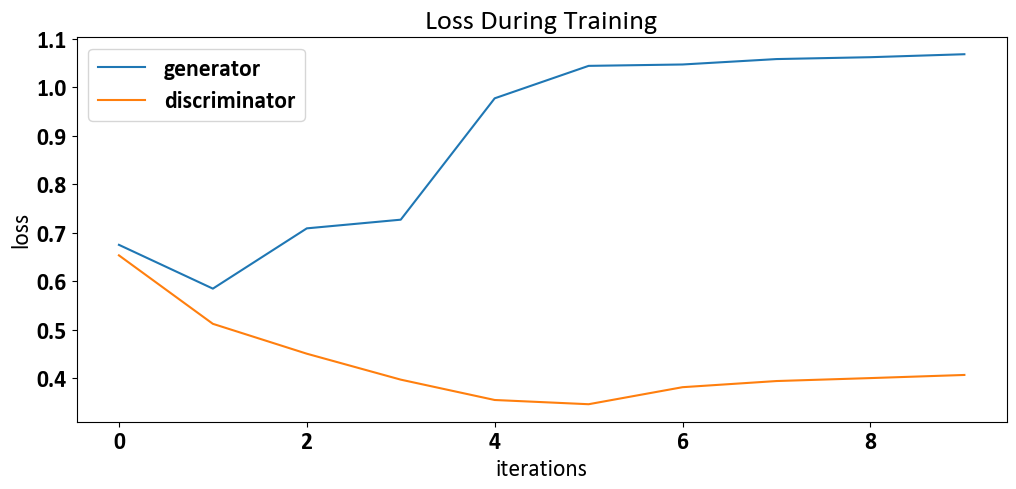

In [45]:
%matplotlib inline

plt.figure(figsize=(12, 5))
plt.title("Loss During Training")
plt.plot(np.array(generator_losses).reshape(batch_size, -1)[:, 0], label="generator")
plt.plot(np.array(discriminator_losses).reshape(batch_size, -1)[:, 0], label="discriminator")
plt.xlabel("iterations")
plt.ylabel("loss")
plt.legend()
plt.show()

In [60]:
nrows = 3
ncols = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 15))
i = 0
for row in range(nrows):
  for col in range(ncols):
    ax = axes[row, col]
    A = plt.imread(
        '../../Drive/MyDrive/GAN/{}_{}.png'.format(i, 0)
    )[:30, :30]
    ax.imshow(A)
    ax.set_title('Epoch {}'.format(i))
    ax.grid(False)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    i += 1
    print("i=",i," | nrows=",row, " | ncols=",col)
fig.tight_layout(pad=.5)

i= 1  | nrows= 0  | ncols= 0
i= 2  | nrows= 0  | ncols= 1
i= 3  | nrows= 0  | ncols= 2
i= 4  | nrows= 1  | ncols= 0
i= 5  | nrows= 1  | ncols= 1
i= 6  | nrows= 1  | ncols= 2
i= 7  | nrows= 2  | ncols= 0
i= 8  | nrows= 2  | ncols= 1
i= 9  | nrows= 2  | ncols= 2


In [61]:
A

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.